## Understanding the Confusion Matrix and Model Selection

A **Confusion Matrix** is a tabular layout that allows visualization of the performance of a supervised learning classification model. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class (or vice versa).

### 1. Key Terminology
For a binary classification scenario (Positive vs. Negative):
*   **True Positive (TP):** The model correctly predicted the positive class (e.g., correctly identified a disease).
*   **True Negative (TN):** The model correctly predicted the negative class (e.g., correctly identified a healthy patient).
*   **False Positive (FP) - Type I Error:** The model incorrectly predicted the positive class (e.g., healthy patient predicted as having a disease).
*   **False Negative (FN) - Type II Error:** The model incorrectly predicted the negative class (e.g., sick patient predicted as healthy).

### 2. Core Metrics Derived from the Confusion Matrix
*   **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$. The overall proportion of correct predictions. Can be misleading if the dataset is highly imbalanced.
*   **Precision (Positive Predictive Value):** $\frac{TP}{TP + FP}$. Out of all predicted positives, how many were actually positive? Crucial when the cost of a False Positive is high (e.g., spam filtering).
*   **Recall (Sensitivity / True Positive Rate):** $\frac{TP}{TP + FN}$. Out of all actual positives, how many did we correctly identify? Crucial when the cost of a False Negative is extremely high (e.g., medical diagnostics or detecting severe security threats).
*   **F1-Score:** $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$. The harmonic mean of Precision and Recall, providing a single balanced metric when you have uneven class distributions.

### 3. How to Select a Model Based on These Metrics
Model selection is heavily dependent on the specific business or clinical goals:

1.  **Minimize False Negatives (High Recall Target):** If missing a positive case has catastrophic consequences (e.g., missing a cancer diagnosis), we choose the model with the highest **Recall**, even if it means tolerating more False Positives.
2.  **Minimize False Positives (High Precision Target):** If acting on a positive prediction is expensive or disruptive (e.g., blocking a user account or executing an expensive engine teardown), we select the model with the highest **Precision**.
3.  **Balanced Performance (High F1-Score Target):** When there is an uneven class distribution and we want a balanced trade-off between Precision and Recall, the **F1-Score** is our primary selection metric.

---

### 🎥 Helpful Resources
For a visual explanation of these evaluation concepts, check out this video: [Confusion Matrix & Evaluation Metrics Video](https://www.youtube.com/watch?v=Kdsp6soqA7o)

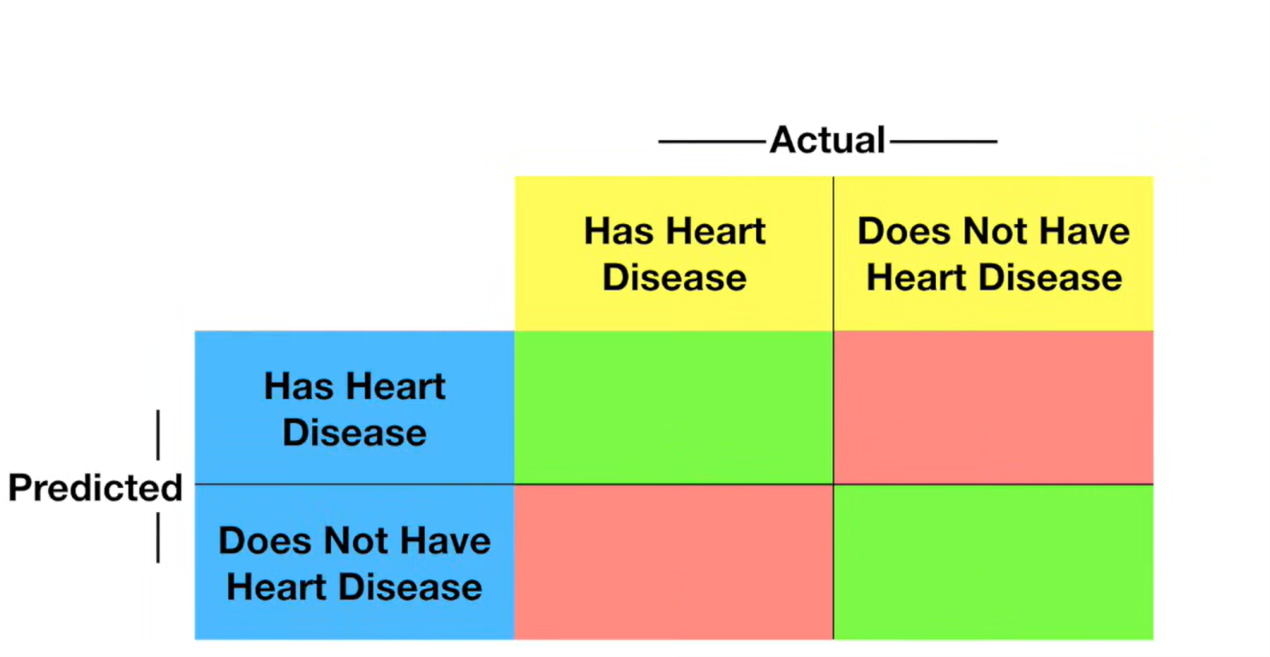

In [1]:
from IPython.display import Image, display

# Display the selected cross-validation image
display(Image(filename='/content/Cross_val.png'))

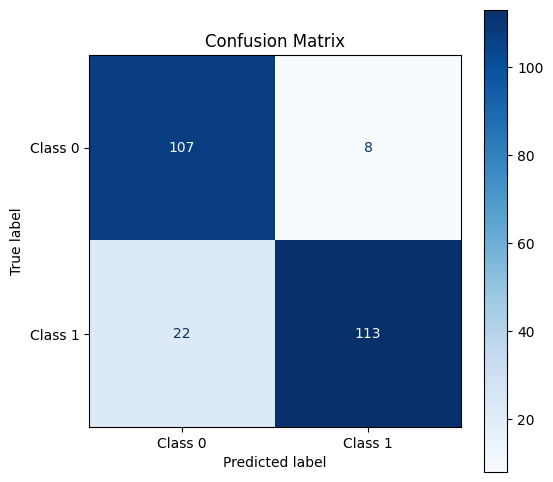

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2. Fit a basic classifier
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# 3. Predict on test data
y_pred = classifier.predict(X_test)

# 4. Generate the confusion matrix and display it
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

# 5. Plot with a styled colormap
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()